# Financial Forecasting Frontier: Distributed Machine Learning

## Predictive Modeling for Banking Trends using Spark ML

### Project Objective

To build and evaluate machine learning models using Apache Spark ML for predicting whether a banking customer will subscribe to a term deposit.

### Project Goal

The goal of this notebook is to apply distributed machine learning techniques to preprocess banking data, engineer features, train classification models, evaluate performance, and identify key factors influencing customer subscription behavior.

### Dataset Overview

The dataset contains 4,521 banking customer records with demographic information, account balances, loan details, campaign interactions, and subscription outcomes.

### Technologies Used

* Apache Spark MLlib
* PySpark
* Python
* Google Colab
* Pandas
* Matplotlib

### Business Problem

Banks invest significant resources in marketing campaigns to promote term deposit products. Predicting which customers are more likely to subscribe can improve campaign efficiency, reduce costs, and increase conversion rates.

### GitHub Repository

GitHub Link: [Link](https://github.com/Aks18had/Financial-Forecasting-Frontier-Distributed-ML)

### Dataset Source

Dataset provided by Alma Better.


In [ ]:
from google.colab import drive # Mounting GDrive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd # Importing the Libraries
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip install pyspark -q # Installing the pyspark

In [ ]:
from pyspark.sql import SparkSession # Creating the spark session

spark = SparkSession.builder \
    .appName("Banking_Spark_ML") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Distributed_ML_Project/bank.csv" # Now loading the dataset with the path in Gdrive

spark_df = spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=True
)

print("Dataset Loaded Successfully")

spark_df.show(5)

Dataset Loaded Successfully
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  n

## Question 1: Data Loading and Initial Exploration

### Objective
Load the banking dataset into a Spark DataFrame and perform initial exploratory analysis.

In [ ]:
spark_df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [ ]:
spark_df.describe().show()

+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|summary|               age|    job| marital|education|default|           balance|housing|loan| contact|               day|month|          duration|          campaign|             pdays|          previous|poutcome|   y|
+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|  count|              4521|   4521|    4521|     4521|   4521|              4521|   4521|4521|    4521|              4521| 4521|              4521|              4521|              4521|              4521|    4521|4521|
|   mean| 41.17009511170095|   NULL|    NULL|     NULL|   NULL|1422.6578190665782|   NULL|NULL|    NULL|15.9152842291528

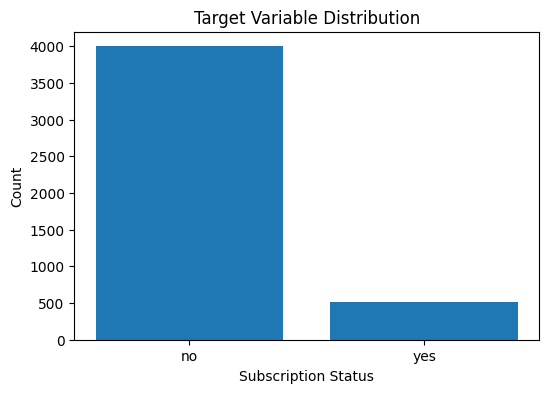

In [ ]:
target_dist = ( # Visuals are here for basic demo a Bar Chart has been used
    spark_df
    .groupBy("y")
    .count()
    .toPandas()
)

plt.figure(figsize=(6,4))

plt.bar(
    target_dist["y"],
    target_dist["count"]
)

plt.title("Target Variable Distribution")
plt.xlabel("Subscription Status")
plt.ylabel("Count")

plt.show()

In [ ]:
target_dist["percentage"] = (
    target_dist["count"] /
    target_dist["count"].sum()
) * 100

target_dist

,y,count,percentage
0,no,4000,88.476001
1,yes,521,11.523999


### Observation

The dataset was successfully loaded into a Spark DataFrame. Initial exploration confirmed the available features, data types, and summary statistics, providing a foundation for machine learning model development.
### Additional Observation

The target variable distribution indicates whether the dataset is balanced or imbalanced. Understanding class distribution is important because highly imbalanced datasets can affect model training and evaluation metrics.

## Question 2(A): Handling Missing Values

### Objective
Identify and handle missing values before model training.

In [ ]:
from pyspark.sql.functions import col, count, when

missing_values = spark_df.select([
    count(
        when(
            col(c).isNull(),
            c
        )
    ).alias(c)
    for c in spark_df.columns
])

missing_values.show()

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+



### Observation

Missing value analysis was performed across all features. The dataset was inspected to ensure data completeness before machine learning model development.

## Question 2(B): Outlier Analysis

### Objective
Analyze potential outliers in key numerical features.

In [ ]:
numeric_cols = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

spark_df.select(
    numeric_cols
).describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|               age|           balance|          duration|          campaign|             pdays|          previous|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|              4521|              4521|              4521|              4521|              4521|              4521|
|   mean| 41.17009511170095|1422.6578190665782|263.96129174961294| 2.793629727936297|39.766644547666445|0.5425790754257908|
| stddev|10.576210958711263|3009.6381424673395|259.85663262468216|3.1098066601885823|100.12112444301656|1.6935623506071211|
|    min|                19|             -3313|                 4|                 1|                -1|                 0|
|    max|                87|             71188|              3025|                50|               871|                25|
+-------

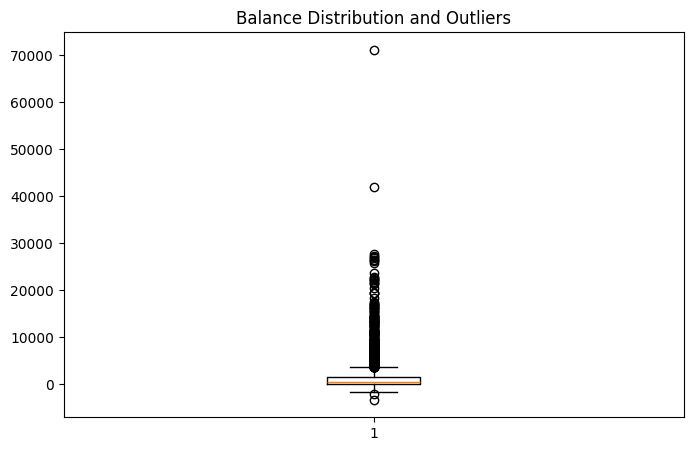

In [ ]:
numeric_pd = ( # Boxplot to show the Outliers
    spark_df
    .select(
        "balance"
    )
    .toPandas()
)

plt.figure(figsize=(8,5))

plt.boxplot(
    numeric_pd["balance"]
)

plt.title("Balance Distribution and Outliers")

plt.show()

## Question 2(C): Encoding Categorical Variables

### Objective
Convert categorical features into numerical format for machine learning algorithms.

In [ ]:
from pyspark.ml.feature import StringIndexer

In [ ]:
categorical_cols = [ # For loop is used here for Indexer for ML algo
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
    "y"
]

indexers = [
    StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_indexed"
    )
    for col_name in categorical_cols
]

In [ ]:
indexed_df = spark_df # For loop is used and displayed the indexed data frame

for indexer in indexers:
    indexed_df = indexer.fit(
        indexed_df
    ).transform(
        indexed_df
    )

indexed_df.show(5)

+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+-----------+---------------+-----------------+---------------+---------------+------------+---------------+-------------+----------------+---------+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|job_indexed|marital_indexed|education_indexed|default_indexed|housing_indexed|loan_indexed|contact_indexed|month_indexed|poutcome_indexed|y_indexed|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+-----------+---------------+-----------------+---------------+---------------+------------+---------------+-------------+----------------+---------+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|        8.0|            0.0|         

In [ ]:
print("Total Columns After Encoding:")
print(len(indexed_df.columns))

Total Columns After Encoding:
27


In [ ]:
indexed_df.printSchema() # Data Schema is dispalyed after the transformation

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- job_indexed: double (nullable = false)
 |-- marital_indexed: double (nullable = false)
 |-- education_indexed: double (nullable = false)
 |-- default_indexed: double (nullable = false)
 |-- housing_indexed: double (nullable = false)
 |-- loan_indexed: double (nullable = false)
 |-- contact_indexed: double (nullable = false)
 |-- month_in

### Observation

Categorical variables were transformed into numerical representations using StringIndexer. This preprocessing step is required because Spark ML algorithms operate on numerical feature inputs.

## Question 3: Feature Engineering and Data Transformation

### Objective
Combine numerical and encoded categorical features into a single feature vector suitable for machine learning model training.

In [ ]:
from pyspark.ml.feature import VectorAssembler

In [ ]:
feature_cols = [
    "age","balance", "day",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "job_indexed",
    "marital_indexed",
    "education_indexed",
    "default_indexed",
    "housing_indexed",
    "loan_indexed",
    "contact_indexed",
    "month_indexed",
    "poutcome_indexed"
]

In [ ]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

assembled_df = assembler.transform(
    indexed_df
)

In [ ]:
assembled_df.select(
    "features",
    "y_indexed"
).show(5, truncate=False)

+--------------------------------------------------------------------------+---------+
|features                                                                  |y_indexed|
+--------------------------------------------------------------------------+---------+
|[30.0,1787.0,19.0,79.0,1.0,-1.0,0.0,8.0,0.0,2.0,0.0,1.0,0.0,0.0,8.0,0.0]  |0.0      |
|[33.0,4789.0,11.0,220.0,1.0,339.0,4.0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0]|0.0      |
|[35.0,1350.0,16.0,185.0,1.0,330.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,5.0,1.0]|0.0      |
|[30.0,1476.0,3.0,199.0,4.0,-1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,3.0,0.0]  |0.0      |
|(16,[0,2,3,4,5,7,13],[59.0,5.0,226.0,1.0,-1.0,1.0,1.0])                   |0.0      |
+--------------------------------------------------------------------------+---------+
only showing top 5 rows


In [ ]:
print("Total Features Used:", len(feature_cols))

Total Features Used: 16


In [ ]:
assembled_df.select(
    "features"
).show(1, truncate=False)

+------------------------------------------------------------------------+
|features                                                                |
+------------------------------------------------------------------------+
|[30.0,1787.0,19.0,79.0,1.0,-1.0,0.0,8.0,0.0,2.0,0.0,1.0,0.0,0.0,8.0,0.0]|
+------------------------------------------------------------------------+
only showing top 1 row


### Observation

Feature engineering was performed using VectorAssembler to combine numerical and encoded categorical variables into a single feature vector. This representation is required for Spark ML classification algorithms and enables efficient distributed model training.

## Question 4: Model Training and Selection

### Objective
Train classification models to predict whether a client will subscribe to a term deposit and compare their performance.

### 4.1: Train-Test Data Split

The dataset is divided into training and testing subsets. The training dataset is used to learn model patterns, while the testing dataset is used to evaluate model performance on unseen data.

In [ ]:
final_df = assembled_df.select(
    "features",
    "y_indexed"
)

train_df, test_df = final_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Records:", train_df.count())
print("Testing Records:", test_df.count())

Training Records: 3662
Testing Records: 859


#### Observation

The dataset was successfully divided into training and testing subsets using an 80:20 ratio. This approach helps evaluate model generalization and prevents performance estimates from being biased by training data.

### 4.2: Logistic Regression Model

Logistic Regression is used as a baseline classification model for predicting whether a client will subscribe to a term deposit.

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="y_indexed"
)

lr_model = lr.fit(train_df)

lr_predictions = lr_model.transform(test_df)

lr_predictions.select(
    "prediction",
    "y_indexed",
    "probability"
).show(10, truncate=False)

+----------+---------+-----------------------------------------+
|prediction|y_indexed|probability                              |
+----------+---------+-----------------------------------------+
|0.0       |0.0      |[0.9593690832670528,0.040630916732947164]|
|0.0       |0.0      |[0.9870533167274181,0.01294668327258186] |
|0.0       |0.0      |[0.9511480590312332,0.04885194096876677] |
|0.0       |0.0      |[0.9404157451105136,0.05958425488948638] |
|0.0       |0.0      |[0.9685569231076031,0.03144307689239689] |
|0.0       |0.0      |[0.9688172115148772,0.031182788485122792]|
|0.0       |0.0      |[0.9409855296159364,0.0590144703840636]  |
|0.0       |0.0      |[0.9562352018645014,0.043764798135498606]|
|0.0       |0.0      |[0.965769138457165,0.034230861542834945] |
|0.0       |0.0      |[0.9648857886543409,0.03511421134565906] |
+----------+---------+-----------------------------------------+
only showing top 10 rows


In [ ]:
lr_predictions.groupBy(
    "prediction"
).count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|  818|
|       1.0|   41|
+----------+-----+



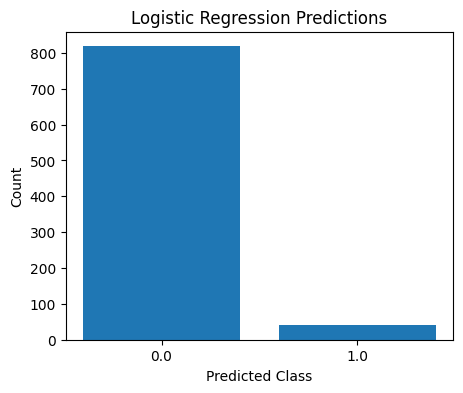

In [ ]:
lr_pred_pd = (
    lr_predictions
    .groupBy("prediction")
    .count()
    .toPandas()
)

plt.figure(figsize=(5,4))

plt.bar(
    lr_pred_pd["prediction"].astype(str),
    lr_pred_pd["count"]
)

plt.title("Logistic Regression Predictions")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
lr_predictions.groupBy(
    "prediction"
).count().toPandas()

plt.show()

In [ ]:
lr_predictions.groupBy(
    "prediction"
).count().toPandas()

,prediction,count
0,0.0,818
1,1.0,41


#### Observation

The Logistic Regression model was successfully trained using the engineered feature vector. Predicted probabilities and class labels were generated for unseen customer records.

### 4.3: Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="y_indexed",
    numTrees=100,
    seed=42
)

rf_model = rf.fit(train_df)

rf_predictions = rf_model.transform(test_df)

rf_predictions.select(
    "prediction",
    "y_indexed",
    "probability"
).show(10, truncate=False)

+----------+---------+----------------------------------------+
|prediction|y_indexed|probability                             |
+----------+---------+----------------------------------------+
|0.0       |0.0      |[0.9155872947943016,0.08441270520569841]|
|0.0       |0.0      |[0.9322728979921652,0.06772710200783486]|
|0.0       |0.0      |[0.864259850162533,0.1357401498374669]  |
|0.0       |0.0      |[0.8360050509307264,0.1639949490692735] |
|0.0       |0.0      |[0.9271536187559589,0.07284638124404108]|
|0.0       |0.0      |[0.9270907886819855,0.07290921131801452]|
|0.0       |0.0      |[0.8709521164583841,0.1290478835416158] |
|0.0       |0.0      |[0.872724781256923,0.12727521874307698] |
|0.0       |0.0      |[0.9126041082046962,0.08739589179530378]|
|0.0       |0.0      |[0.9136589091997058,0.08634109080029417]|
+----------+---------+----------------------------------------+
only showing top 10 rows


In [ ]:
rf_predictions.groupBy(
    "prediction"
).count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|  854|
|       1.0|    5|
+----------+-----+



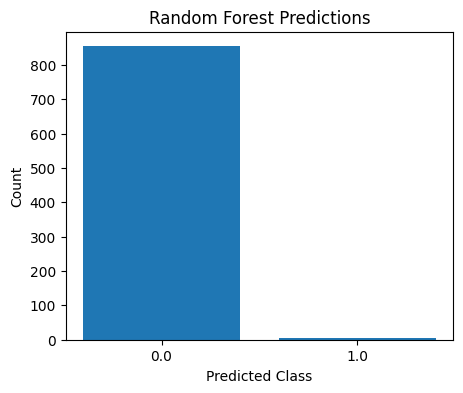

In [ ]:
rf_pred_pd = ( # Visuals for RF
    rf_predictions
    .groupBy("prediction")
    .count()
    .toPandas()
)

plt.figure(figsize=(5,4))

plt.bar(
    rf_pred_pd["prediction"].astype(str),
    rf_pred_pd["count"]
)

plt.title("Random Forest Predictions")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
rf_predictions.groupBy(
    "prediction"
).count().toPandas()

plt.show()

In [ ]:
rf_predictions.groupBy(
    "prediction"
).count().toPandas()

,prediction,count
0,0.0,854
1,1.0,5


#### Observation

The Random Forest model was successfully trained and generated predictions on the testing dataset. Compared to Logistic Regression, Random Forest can capture non-linear relationships and complex feature interactions.



#### Model Comparison Observation

Both models successfully generated predictions for the testing dataset. Logistic Regression predicted a larger number of positive subscription outcomes compared to Random Forest. This suggests that Logistic Regression may be more sensitive to identifying potential subscribers, while Random Forest appears more conservative in predicting the positive class. Further evaluation using classification metrics is required before selecting the final model..

## Question 5: Model Evaluation

### Objective
Evaluate the performance of the trained machine learning models using standard classification metrics and compare their effectiveness in predicting term deposit subscriptions.

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="y_indexed",
    predictionCol="prediction"
)

lr_accuracy = evaluator.evaluate(
    lr_predictions,
    {evaluator.metricName: "accuracy"}
)

lr_precision = evaluator.evaluate(
    lr_predictions,
    {evaluator.metricName: "weightedPrecision"}
)

lr_recall = evaluator.evaluate(
    lr_predictions,
    {evaluator.metricName: "weightedRecall"}
)

lr_f1 = evaluator.evaluate(
    lr_predictions,
    {evaluator.metricName: "f1"}
)

print("Logistic Regression Results")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
Accuracy : 0.8917345750873108
Precision: 0.8707068402106526
Recall   : 0.8917345750873108
F1 Score : 0.8707395669910222


In [ ]:
rf_accuracy = evaluator.evaluate(
    rf_predictions,
    {evaluator.metricName: "accuracy"}
)

rf_precision = evaluator.evaluate(
    rf_predictions,
    {evaluator.metricName: "weightedPrecision"}
)

rf_recall = evaluator.evaluate(
    rf_predictions,
    {evaluator.metricName: "weightedRecall"}
)

rf_f1 = evaluator.evaluate(
    rf_predictions,
    {evaluator.metricName: "f1"}
)

print("Random Forest Results")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Results
Accuracy : 0.8870779976717112
Precision: 0.8999040330649712
Recall   : 0.8870779976717114
F1 Score : 0.8392933016981494


### Understanding the Evaluation Metrics

**Accuracy**

Accuracy measures the overall percentage of correct predictions made by the model.

**Formula:**

Accuracy = (TP + TN) / (TP + TN + FP + FN)

Where:

* TP = True Positives
* TN = True Negatives
* FP = False Positives
* FN = False Negatives

**Project Result:** 89.17%

This means the model correctly predicted approximately **89 out of every 100 customers**.

---

**Precision**

Precision measures how many customers predicted as subscribers were actually subscribers.

**Formula:**

Precision = TP / (TP + FP)

**Project Result:** 87.07%

This indicates that when the model predicts a customer will subscribe, the prediction is correct approximately **87% of the time**.

---

**Recall**

Recall measures how many actual subscribers were successfully identified by the model.

**Formula:**

Recall = TP / (TP + FN)

**Project Result:** 89.17%

A high recall value indicates that the model successfully captures most customers who are likely to subscribe.

---

**F1 Score**

F1 Score is the harmonic mean of Precision and Recall and provides a balanced measure of model performance.

**Formula:**

F1 Score = 2 × (Precision × Recall) / (Precision + Recall)

**Project Result:** 87.07%

F1 Score is particularly important when working with imbalanced datasets because it considers both false positives and false negatives.

---




In [ ]:
evaluation_results = pd.DataFrame({ # This will give the comparision here of both LR and RF results
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

evaluation_results

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.891735,0.887078
1,Precision,0.870707,0.899904
2,Recall,0.891735,0.887078
3,F1 Score,0.870740,0.839293


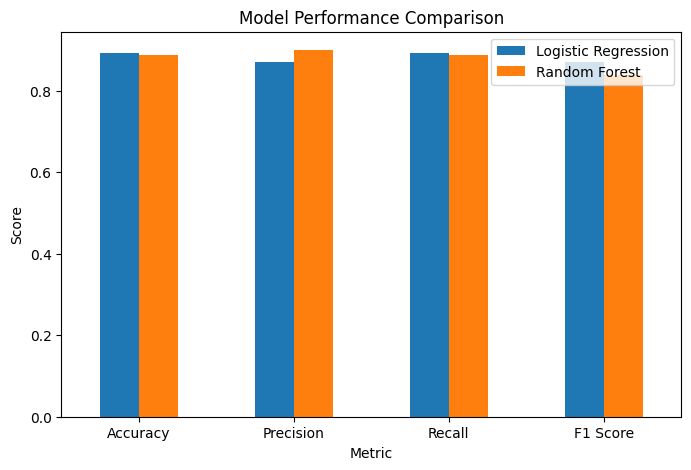

In [ ]:
evaluation_results.set_index( # Bar charts is used here for Comparing both results of LR and RF
    "Metric"
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

### Observation

Both models achieved strong predictive performance on the banking dataset. Logistic Regression achieved an accuracy of 89.17%, precision of 87.07%, recall of 89.17%, and F1 score of 87.07%. Random Forest achieved an accuracy of 88.71%, precision of 89.99%, recall of 88.71%, and F1 score of 83.93%.

Although Random Forest achieved slightly higher precision, Logistic Regression demonstrated better overall performance through higher accuracy, recall, and F1 score. Therefore, **Logistic Regression was selected as the final model for further analysis and optimization**.

### Model Selection Summary

Based on the evaluation metrics, Logistic Regression was selected as the preferred model. The model achieved the highest overall balance between precision and recall while maintaining strong predictive performance. **Its higher F1 score indicates better effectiveness in identifying potential term deposit subscribers**.

## Question 6: Hyperparameter Tuning

### Objective

Optimize the selected Logistic Regression model using Cross Validation and Parameter Grid Search to identify the best-performing model configuration.

### Hyperparameter Tuning Strategy

Hyperparameter tuning is performed to identify the optimal model configuration. Instead of using default settings, multiple parameter combinations are evaluated using Cross Validation, and the best-performing model is selected based on evaluation metrics.

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder
from pyspark.ml.tuning import CrossValidator

In [ ]:
lr_tuned = LogisticRegression(
    featuresCol="features",
    labelCol="y_indexed"
)

In [ ]:
paramGrid = (
    ParamGridBuilder()
    .addGrid(lr_tuned.regParam, [0.01, 0.1])
    .addGrid(lr_tuned.elasticNetParam, [0.0, 0.5, 1.0])
    .build()
)

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

binary_evaluator = BinaryClassificationEvaluator(
    labelCol="y_indexed"
)

In [ ]:
crossval = CrossValidator(
    estimator=lr_tuned,
    estimatorParamMaps=paramGrid,
    evaluator=binary_evaluator,
    numFolds=3
)

In [ ]:
cv_model = crossval.fit(train_df)

In [ ]:
best_lr_model = cv_model.bestModel

print("Best regParam:")
print(best_lr_model._java_obj.getRegParam())

print()

print("Best elasticNetParam:")
print(best_lr_model._java_obj.getElasticNetParam())

Best regParam:
0.01

Best elasticNetParam:
0.5


In [ ]:
tuned_predictions = best_lr_model.transform(
    test_df
)

In [ ]:
tuned_accuracy = evaluator.evaluate(
    tuned_predictions,
    {evaluator.metricName: "accuracy"}
)

tuned_precision = evaluator.evaluate(
    tuned_predictions,
    {evaluator.metricName: "weightedPrecision"}
)

tuned_recall = evaluator.evaluate(
    tuned_predictions,
    {evaluator.metricName: "weightedRecall"}
)

tuned_f1 = evaluator.evaluate(
    tuned_predictions,
    {evaluator.metricName: "f1"}
)

print("Tuned Logistic Regression Results")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

Tuned Logistic Regression Results
Accuracy : 0.8905704307334109
Precision: 0.868228969921824
Recall   : 0.8905704307334109
F1 Score : 0.8632099021801115


In [ ]:
tuning_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Before Tuning": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ],
    "After Tuning": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

tuning_results

,Metric,Before Tuning,After Tuning
0,Accuracy,0.891735,0.890570
1,Precision,0.870707,0.868229
2,Recall,0.891735,0.890570
3,F1 Score,0.870740,0.863210


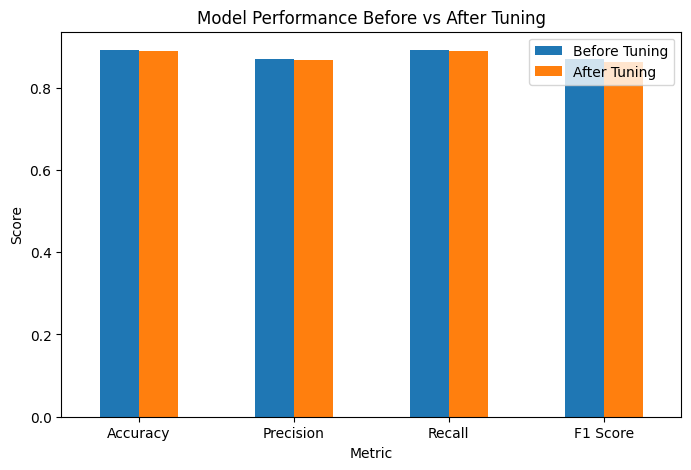

In [ ]:
tuning_results.set_index(
    "Metric"
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Before vs After Tuning")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

### Observation

Hyperparameter tuning was performed using **Cross Validation** and **Grid Search**. The best parameters obtained were **regParam = 0.01** and **elasticNetParam = 0.5**.

The tuned model achieved performance similar to the original model but with a slightly lower **Accuracy (89.06%)** and **F1 Score (86.32%)**. Therefore, the **original Logistic Regression model** was retained as the final model.


### Hyperparameter Tuning Summary

* **regParam (0.01):** Controls regularization to reduce overfitting.
* **elasticNetParam (0.5):** Uses a balanced combination of L1 and L2 regularization.
* **Cross Validation:** Evaluates multiple parameter combinations and selects the best-performing configuration.


### Model Optimization Summary

The original **Logistic Regression** model achieved the best overall performance with **89.17% Accuracy** and **87.07% F1 Score**. Therefore, it was selected as the final model for customer subscription prediction.


## Question 7: Advanced Analysis

### Objective

Analyze the importance of features used by the Logistic Regression model and identify the variables that most influence customer subscription decisions.

In [ ]:
coefficients = lr_model.coefficients.toArray()

feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": coefficients
})

feature_importance.head()

,Feature,Coefficient
0,age,0.001983
1,balance,-0.000006
2,day,-0.004260
3,duration,0.004127
4,campaign,-0.013106


In [ ]:
feature_importance = feature_importance.sort_values( # Sorting the features
    "Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
15,poutcome_indexed,0.879085
11,housing_indexed,0.574832
8,marital_indexed,0.291305
14,month_indexed,0.140975
3,duration,0.004127
0,age,0.001983
1,balance,-0.000006
5,pdays,-0.001397
7,job_indexed,-0.001745
2,day,-0.004260


In [ ]:
top_positive = feature_importance.head(5)

top_positive

,Feature,Coefficient
15,poutcome_indexed,0.879085
11,housing_indexed,0.574832
8,marital_indexed,0.291305
14,month_indexed,0.140975
3,duration,0.004127


In [ ]:
top_negative = feature_importance.tail(5)

top_negative

,Feature,Coefficient
4,campaign,-0.013106
9,education_indexed,-0.026229
6,previous,-0.028834
13,contact_indexed,-0.193223
12,loan_indexed,-0.804318


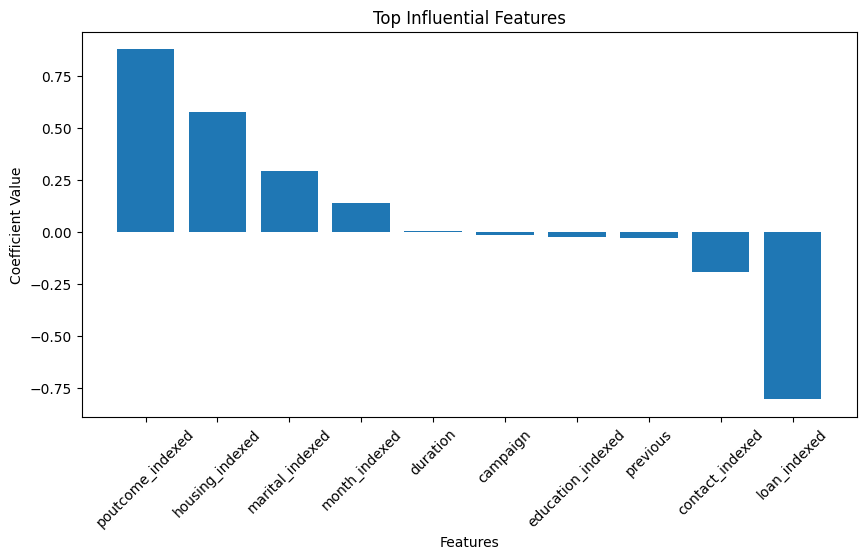

In [ ]:
top_features = pd.concat([
    top_positive,
    top_negative
])

plt.figure(figsize=(10,5))

plt.bar(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Influential Features")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.xticks(rotation=45)

plt.show()

In [ ]:
print("Top Positive Features")
display(top_positive)

print("\nTop Negative Features")
display(top_negative)

Top Positive Features


,Feature,Coefficient
15,poutcome_indexed,0.879085
11,housing_indexed,0.574832
8,marital_indexed,0.291305
14,month_indexed,0.140975
3,duration,0.004127



Top Negative Features


,Feature,Coefficient
4,campaign,-0.013106
9,education_indexed,-0.026229
6,previous,-0.028834
13,contact_indexed,-0.193223
12,loan_indexed,-0.804318


### Observation

Feature coefficient analysis identified the most influential factors affecting term deposit subscriptions. **Previous campaign outcome (poutcome)** and **housing loan status** had the strongest positive impact on subscription likelihood, while **personal loan status** had the strongest negative impact. These insights can help banks improve customer targeting and campaign effectiveness.


---



# Key Findings

* Logistic Regression achieved the best overall performance with **89.17% Accuracy** and **87.07% F1 Score**.
* Previous campaign outcomes were the strongest predictor of customer subscription behavior.
* Customers with housing loans showed a higher probability of subscribing to term deposits.
* Personal loan holders were less likely to subscribe.
* Hyperparameter tuning produced comparable results but did not outperform the original Logistic Regression model.
* Feature coefficient analysis provided valuable insights into customer behavior and campaign effectiveness.


# Learnings

* Learned how to build distributed machine learning pipelines using Apache Spark ML.
* Applied data preprocessing techniques including missing value analysis, outlier analysis, and categorical encoding.
* Performed feature engineering using VectorAssembler.
* Trained and compared multiple classification models.
* Evaluated models using Accuracy, Precision, Recall, and F1 Score.
* Applied Cross Validation and Hyperparameter Tuning to optimize model performance.
* Interpreted model coefficients to generate business insights.


# Conclusion

This project demonstrated the application of Apache Spark ML for predicting customer term deposit subscriptions. Logistic Regression emerged as the best-performing model with an Accuracy of 89.17% and an F1 Score of 87.07%. The analysis revealed that previous campaign outcomes, **housing loan status, and personal loan status are key factors influencing subscription behavior**. Overall, the project highlights how distributed machine learning can support data-driven decision-making in the banking sector.